In [2]:
import pandas as pd
import matplotlib.pyplot as plt

# Load cleaned biometrics data
file_path = "cleaned_output/Fitbit_Ir_cleaned/Fitbit_Ir_biometrics_cleaned.xlsx"
df = pd.read_excel(file_path)

df.head()


,time,value,unit,data_source,measurement_type,medical_codes,tags,source_file,days,enabled,min,max
0,2025-07-04 21:32:00,164,MG_DL,MANUAL,UNSPECIFIED,NaN,before bed,Glucose 202507.csv,NaN,NaN,0,0
1,2025-07-04 16:08:00,150,MG_DL,MANUAL,UNSPECIFIED,14760-3:LOINC,after meal,Glucose 202507.csv,NaN,NaN,0,0
2,2025-07-04 09:31:00,103,MG_DL,MANUAL,UNSPECIFIED,14760-3:LOINC,after meal,Glucose 202507.csv,NaN,NaN,0,0
3,2025-07-04 06:10:00,108,MG_DL,MANUAL,UNSPECIFIED,41604-0:LOINC,fasting,Glucose 202507.csv,NaN,NaN,0,0
4,2025-07-07 15:17:00,205,MG_DL,MANUAL,UNSPECIFIED,14760-3:LOINC,after meal,Glucose 202507.csv,NaN,NaN,0,0


In [3]:
df.columns


Index(['time', 'value', 'unit', 'data_source', 'measurement_type',
       'medical_codes', 'tags', 'source_file', 'days', 'enabled', 'min',
       'max'],
      dtype='object')

In [6]:
import pandas as pd
import matplotlib.pyplot as plt

# Ensure lowercase (already is, but safe)
df.columns = df.columns.str.lower()

# Convert time column
df["time"] = pd.to_datetime(df["time"], errors="coerce")

# Drop rows without valid glucose or time
df = df.dropna(subset=["time", "value"])

# Sort chronologically
df = df.sort_values("time")

df.head()


,time,value,unit,data_source,measurement_type,medical_codes,tags,source_file,days,enabled,min,max
3,2025-07-04 06:10:00,108,MG_DL,MANUAL,UNSPECIFIED,41604-0:LOINC,fasting,Glucose 202507.csv,NaN,NaN,0,0
2,2025-07-04 09:31:00,103,MG_DL,MANUAL,UNSPECIFIED,14760-3:LOINC,after meal,Glucose 202507.csv,NaN,NaN,0,0
1,2025-07-04 16:08:00,150,MG_DL,MANUAL,UNSPECIFIED,14760-3:LOINC,after meal,Glucose 202507.csv,NaN,NaN,0,0
0,2025-07-04 21:32:00,164,MG_DL,MANUAL,UNSPECIFIED,NaN,before bed,Glucose 202507.csv,NaN,NaN,0,0
6,2025-07-07 06:02:00,117,MG_DL,MANUAL,UNSPECIFIED,41604-0:LOINC,fasting,Glucose 202507.csv,NaN,NaN,0,0


In [11]:
df.tail(10)


,time,value,unit,data_source,measurement_type,medical_codes,tags,source_file,days,enabled,min,max,date
4,2025-07-07 15:17:00,205,MG_DL,MANUAL,UNSPECIFIED,14760-3:LOINC,after meal,Glucose 202507.csv,NaN,NaN,0,0,2025-07-07
10,2025-07-15 06:02:00,155,MG_DL,MANUAL,UNSPECIFIED,41604-0:LOINC,fasting,Glucose 202507.csv,NaN,NaN,0,0,2025-07-15
9,2025-07-15 09:39:00,138,MG_DL,MANUAL,UNSPECIFIED,14760-3:LOINC,after meal,Glucose 202507.csv,NaN,NaN,0,0,2025-07-15
8,2025-07-15 15:47:00,202,MG_DL,MANUAL,UNSPECIFIED,14760-3:LOINC,after meal,Glucose 202507.csv,NaN,NaN,0,0,2025-07-15
7,2025-07-15 21:58:00,191,MG_DL,MANUAL,UNSPECIFIED,NaN,before bed,Glucose 202507.csv,NaN,NaN,0,0,2025-07-15
14,2025-07-23 06:05:00,165,MG_DL,MANUAL,UNSPECIFIED,41604-0:LOINC,fasting,Glucose 202507.csv,NaN,NaN,0,0,2025-07-23
13,2025-07-23 09:36:00,144,MG_DL,MANUAL,UNSPECIFIED,14760-3:LOINC,after meal,Glucose 202507.csv,NaN,NaN,0,0,2025-07-23
12,2025-07-23 15:20:00,210,MG_DL,MANUAL,UNSPECIFIED,14760-3:LOINC,after meal,Glucose 202507.csv,NaN,NaN,0,0,2025-07-23
11,2025-07-23 21:32:00,198,MG_DL,MANUAL,UNSPECIFIED,NaN,before bed,Glucose 202507.csv,NaN,NaN,0,0,2025-07-23
15,2025-12-15 06:00:00,0,NaN,NaN,NaN,NaN,NaN,Glucose Reminders.csv,MON:WED:FRI,1.0,0,0,2025-12-15


In [12]:
# 1. Ensure datetime
df["time"] = pd.to_datetime(df["time"], errors="coerce")

# 2. REMOVE non-measurement rows
df = df[
    (df["value"] > 40) &                # physiological glucose lower bound
    (df["unit"] == "MG_DL") &            # valid unit
    (df["data_source"].notna())          # real measurement
]

# 3. Sort chronologically
df = df.sort_values("time")

df


,time,value,unit,data_source,measurement_type,medical_codes,tags,source_file,days,enabled,min,max,date
3,2025-07-04 06:10:00,108,MG_DL,MANUAL,UNSPECIFIED,41604-0:LOINC,fasting,Glucose 202507.csv,NaN,NaN,0,0,2025-07-04
2,2025-07-04 09:31:00,103,MG_DL,MANUAL,UNSPECIFIED,14760-3:LOINC,after meal,Glucose 202507.csv,NaN,NaN,0,0,2025-07-04
1,2025-07-04 16:08:00,150,MG_DL,MANUAL,UNSPECIFIED,14760-3:LOINC,after meal,Glucose 202507.csv,NaN,NaN,0,0,2025-07-04
0,2025-07-04 21:32:00,164,MG_DL,MANUAL,UNSPECIFIED,NaN,before bed,Glucose 202507.csv,NaN,NaN,0,0,2025-07-04
6,2025-07-07 06:02:00,117,MG_DL,MANUAL,UNSPECIFIED,41604-0:LOINC,fasting,Glucose 202507.csv,NaN,NaN,0,0,2025-07-07
5,2025-07-07 09:33:00,104,MG_DL,MANUAL,UNSPECIFIED,14760-3:LOINC,after meal,Glucose 202507.csv,NaN,NaN,0,0,2025-07-07
4,2025-07-07 15:17:00,205,MG_DL,MANUAL,UNSPECIFIED,14760-3:LOINC,after meal,Glucose 202507.csv,NaN,NaN,0,0,2025-07-07
10,2025-07-15 06:02:00,155,MG_DL,MANUAL,UNSPECIFIED,41604-0:LOINC,fasting,Glucose 202507.csv,NaN,NaN,0,0,2025-07-15
9,2025-07-15 09:39:00,138,MG_DL,MANUAL,UNSPECIFIED,14760-3:LOINC,after meal,Glucose 202507.csv,NaN,NaN,0,0,2025-07-15
8,2025-07-15 15:47:00,202,MG_DL,MANUAL,UNSPECIFIED,14760-3:LOINC,after meal,Glucose 202507.csv,NaN,NaN,0,0,2025-07-15


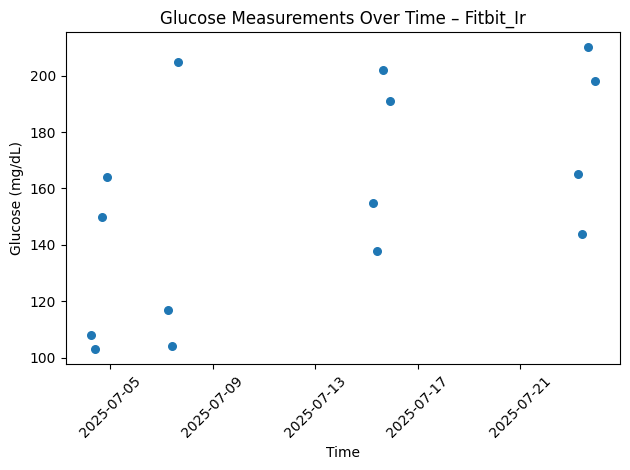

In [13]:
import matplotlib.pyplot as plt

plt.figure()
plt.scatter(df["time"], df["value"], s=30)

plt.xlabel("Time")
plt.ylabel("Glucose (mg/dL)")
plt.title("Glucose Measurements Over Time – Fitbit_Ir")

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


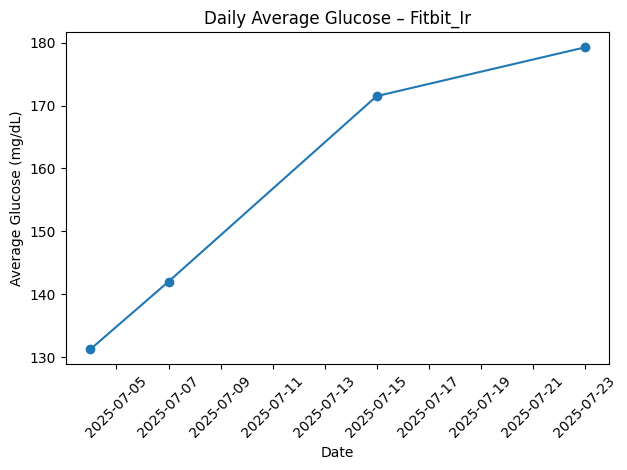

In [14]:
df["date"] = df["time"].dt.date
daily_avg = df.groupby("date")["value"].mean()

plt.figure()
plt.plot(daily_avg.index, daily_avg.values, marker="o")

plt.xlabel("Date")
plt.ylabel("Average Glucose (mg/dL)")
plt.title("Daily Average Glucose – Fitbit_Ir")

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


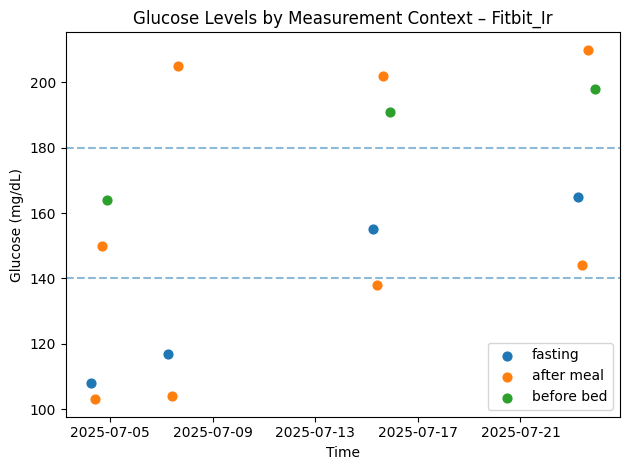

In [15]:
plt.figure()

for tag, color in [
    ("fasting", "green"),
    ("after meal", "red"),
    ("before bed", "blue")
]:
    subset = df[df["tags"] == tag]
    plt.scatter(subset["time"], subset["value"], label=tag, s=40)

plt.axhline(140, linestyle="--", alpha=0.5)
plt.axhline(180, linestyle="--", alpha=0.5)

plt.xlabel("Time")
plt.ylabel("Glucose (mg/dL)")
plt.title("Glucose Levels by Measurement Context – Fitbit_Ir")
plt.legend()

plt.tight_layout()
plt.show()


In [2]:
import pandas as pd

df = pd.read_excel(
    "cleaned_output/Fitbit_Ir/Fitbit_Ir_biometrics.xlsx"
)

df.head()


,time,value,unit,data_source,measurement_type,medical_codes,tags,source_file,days,enabled,min,max
0,2025-07-04 21:32:00,164,MG_DL,MANUAL,UNSPECIFIED,NaN,before bed,Glucose 202507.csv,NaN,NaN,0,0
1,2025-07-04 16:08:00,150,MG_DL,MANUAL,UNSPECIFIED,14760-3:LOINC,after meal,Glucose 202507.csv,NaN,NaN,0,0
2,2025-07-04 09:31:00,103,MG_DL,MANUAL,UNSPECIFIED,14760-3:LOINC,after meal,Glucose 202507.csv,NaN,NaN,0,0
3,2025-07-04 06:10:00,108,MG_DL,MANUAL,UNSPECIFIED,41604-0:LOINC,fasting,Glucose 202507.csv,NaN,NaN,0,0
4,2025-07-07 15:17:00,205,MG_DL,MANUAL,UNSPECIFIED,14760-3:LOINC,after meal,Glucose 202507.csv,NaN,NaN,0,0


In [3]:
# Convert time column (safety)
df["time"] = pd.to_datetime(df["time"], errors="coerce")

# Remove non-measurement rows again (safe)
df = df[
    (df["value"] > 40) &
    (df["unit"] == "MG_DL") &
    (df["data_source"].notna())
]

# Create date column
df["date"] = df["time"].dt.date

# Daily average glucose
daily_glucose = (
    df.groupby("date")["value"]
    .mean()
    .reset_index(name="avg_glucose")
)

daily_glucose


,date,avg_glucose
0,2025-07-04,131.25
1,2025-07-07,142.00
2,2025-07-15,171.50
3,2025-07-23,179.25


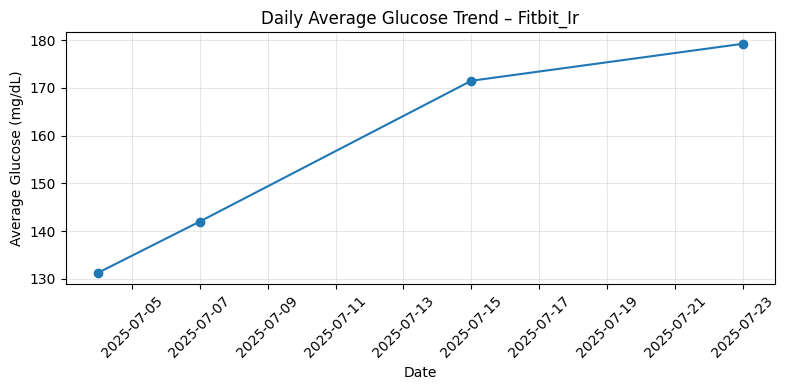

In [6]:
import matplotlib.pyplot as plt
plt.figure(figsize=(8,4))
plt.plot(
    daily_glucose["date"],
    daily_glucose["avg_glucose"],
    marker="o"
)

plt.xlabel("Date")
plt.ylabel("Average Glucose (mg/dL)")
plt.title("Daily Average Glucose Trend – Fitbit_Ir")

plt.xticks(rotation=45)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


In [8]:
fasting_df = df[df["tags"] == "fasting"].copy()

fasting_df["date"] = fasting_df["time"].dt.date
fasting_df = fasting_df.sort_values("date")

fasting_df


,time,value,unit,data_source,measurement_type,medical_codes,tags,source_file,days,enabled,min,max,date
3,2025-07-04 06:10:00,108,MG_DL,MANUAL,UNSPECIFIED,41604-0:LOINC,fasting,Glucose 202507.csv,NaN,NaN,0,0,2025-07-04
6,2025-07-07 06:02:00,117,MG_DL,MANUAL,UNSPECIFIED,41604-0:LOINC,fasting,Glucose 202507.csv,NaN,NaN,0,0,2025-07-07
10,2025-07-15 06:02:00,155,MG_DL,MANUAL,UNSPECIFIED,41604-0:LOINC,fasting,Glucose 202507.csv,NaN,NaN,0,0,2025-07-15
14,2025-07-23 06:05:00,165,MG_DL,MANUAL,UNSPECIFIED,41604-0:LOINC,fasting,Glucose 202507.csv,NaN,NaN,0,0,2025-07-23


In [9]:
fasting_daily = (
    fasting_df
    .groupby("date")["value"]
    .mean()
    .reset_index(name="fasting_glucose")
)

fasting_daily


,date,fasting_glucose
0,2025-07-04,108.0
1,2025-07-07,117.0
2,2025-07-15,155.0
3,2025-07-23,165.0


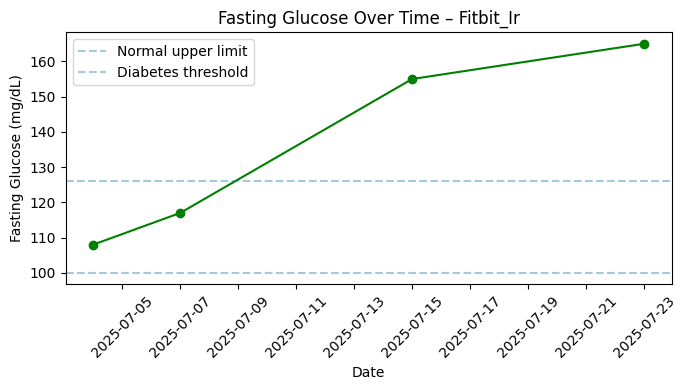

In [10]:
import matplotlib.pyplot as plt

plt.figure(figsize=(7,4))
plt.plot(
    fasting_daily["date"],
    fasting_daily["fasting_glucose"],
    marker="o",
    color="green"
)

plt.xlabel("Date")
plt.ylabel("Fasting Glucose (mg/dL)")
plt.title("Fasting Glucose Over Time – Fitbit_Ir")

plt.axhline(100, linestyle="--", alpha=0.4, label="Normal upper limit")
plt.axhline(126, linestyle="--", alpha=0.4, label="Diabetes threshold")
plt.legend()

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


In [27]:
import pandas as pd

# RELOAD the sleep file fresh
sleep_df = pd.read_excel(
    "cleaned_output/Fitbit_Ir_cleaned/Fitbit_Ir_sleep_score_cleaned.xlsx"
)

# Check columns (optional sanity check)
print(sleep_df.columns)

# Convert timestamp
sleep_df["timestamp"] = pd.to_datetime(
    sleep_df["timestamp"],
    errors="coerce"
)

# Create date column
sleep_df["date"] = sleep_df["timestamp"].dt.date

# Rename for consistency
sleep_df = sleep_df.rename(columns={"overall_score": "sleep_score"})

# Keep only required columns
sleep_df = sleep_df[["date", "sleep_score"]]

sleep_df.head()


Index(['sleep_log_entry_id', 'timestamp', 'overall_score', 'composition_score',
       'revitalization_score', 'duration_score', 'deep_sleep_in_minutes',
       'resting_heart_rate', 'restlessness', 'source_file'],
      dtype='object')


,date,sleep_score
0,2025-07-27,65
1,2025-07-26,61
2,2025-07-25,78
3,2025-07-24,78
4,2025-07-23,69


In [28]:
sleep_df["next_day"] = sleep_df["date"] + pd.Timedelta(days=1)

fasting_sleep = pd.merge(
    fasting_daily,
    sleep_df,
    left_on="date",
    right_on="next_day",
    how="inner"
)

fasting_sleep


,date_x,fasting_glucose,date_y,sleep_score,next_day
0,2025-07-07,117.0,2025-07-06,79,2025-07-07
1,2025-07-15,155.0,2025-07-14,73,2025-07-15
2,2025-07-23,165.0,2025-07-22,75,2025-07-23


In [29]:
# Shift sleep to next day
sleep_df["next_day"] = sleep_df["date"] + pd.Timedelta(days=1)

# Merge with fasting glucose
fasting_sleep = pd.merge(
    fasting_daily,
    sleep_df,
    left_on="date",
    right_on="next_day",
    how="inner"
)

fasting_sleep


,date_x,fasting_glucose,date_y,sleep_score,next_day
0,2025-07-07,117.0,2025-07-06,79,2025-07-07
1,2025-07-15,155.0,2025-07-14,73,2025-07-15
2,2025-07-23,165.0,2025-07-22,75,2025-07-23


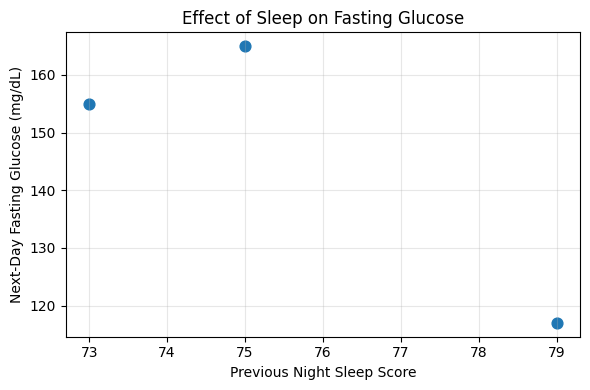

In [30]:
import matplotlib.pyplot as plt

plt.figure(figsize=(6,4))
plt.scatter(
    fasting_sleep["sleep_score"],
    fasting_sleep["fasting_glucose"],
    s=60
)

plt.xlabel("Previous Night Sleep Score")
plt.ylabel("Next-Day Fasting Glucose (mg/dL)")
plt.title("Effect of Sleep on Fasting Glucose")

plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


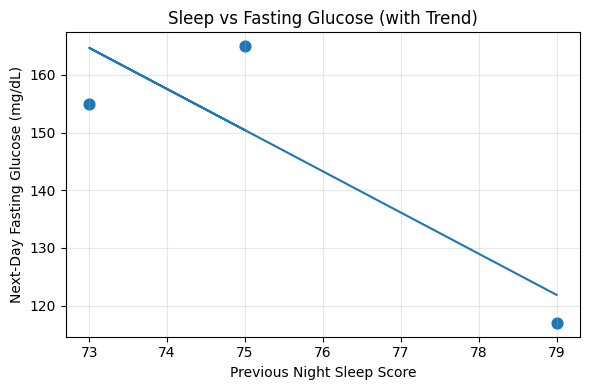

In [31]:
import numpy as np

x = fasting_sleep["sleep_score"]
y = fasting_sleep["fasting_glucose"]

m, b = np.polyfit(x, y, 1)

plt.figure(figsize=(6,4))
plt.scatter(x, y, s=60)
plt.plot(x, m*x + b)

plt.xlabel("Previous Night Sleep Score")
plt.ylabel("Next-Day Fasting Glucose (mg/dL)")
plt.title("Sleep vs Fasting Glucose (with Trend)")

plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


In [32]:
fasting_sleep[["sleep_score", "fasting_glucose"]].corr()


,sleep_score,fasting_glucose
sleep_score,1.000000,-0.861685
fasting_glucose,-0.861685,1.000000
